In [1]:
from data import get_dataset_dir, check_dataset, create_yolo_dataset
from pathlib import Path
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
dataset_dir = get_dataset_dir()

In [3]:
dataset_dir

PosixPath('/Users/anatolii/.cache/kagglehub/datasets/psvishnu/pennfudan-database-for-pedestrian-detection-zip/versions/1/PennFudanPed')

Images are located in PNGImages folder  

GT in Annotation folder as txt file. It contains the full img pathname, size and bb coordinates.  
Example:  

\# Compatible with PASCAL Annotation Version 1.00
Image filename : "PennFudanPed/PNGImages/FudanPed00002.png"
Image size (X x Y x C) : 455 x 414 x 3
Database : "The Penn-Fudan-Pedestrian Database"
Objects with ground truth : 1 { "PASpersonWalking" }
\# Note there may be some objects not included in the ground truth list for they are severe-occluded
\# or have very small size.
\# Top left pixel co-ordinates : (1, 1)
\# Details for pedestrian 1 ("PASpersonWalking")
Original label for object 1 "PASpersonWalking" : "PennFudanPed"
Bounding box for object 1 "PASpersonWalking" (Xmin, Ymin) - (Xmax, Ymax) : (68, 93) - (191, 380)
Pixel mask for object 1 "PASpersonWalking" : "PennFudanPed/PedMasks/FudanPed00002_mask.png"



What I want to do first:  
A. Validates file linking

For every annotation entry:  
	•	image path exists  
	•	image can be opened (width/height readable)  
	•	all referenced images are unique (or intentionally duplicated)  

B. Validates bounding boxes  

For every box (xmin, ymin, xmax, ymax):  
	•	type: numeric  
	•	xmin < xmax and ymin < ymax  
	•	within image bounds: 0 ≤ xmin < xmax ≤ W, 0 ≤ ymin < ymax ≤ H  
	•	filter/flag boxes with tiny area (e.g., < 4×4 pixels) as “suspicious”  

C. Summarizes the dataset (quick EDA)  

Print/plot (even just printed stats is fine):  
	•	number of images  
	•	distribution: boxes per image (min/median/max)  
	•	distribution of box areas (relative area = box_area / image_area)  
	•	top 5 images with most boxes  
	•	top 5 images with smallest boxes  


In [4]:
img_dir = Path(dataset_dir / "PNGImages")

In [5]:
len(list(img_dir.glob("*.png")))

170

In [6]:
annotation_dir = Path(dataset_dir / "Annotation")

In [7]:
# in annotation dir take every file and pars to find "Image size (X x Y x C) : 455 x 414 x 3"
# save w and h to the list
def get_all_img_sizes(path):
    path = Path(path)
    img_sizes = []
    pattern = re.compile(r"Image size \(X x Y x C\)\s*:\s*(\d+)\s*x\s*(\d+)\s*x\s*\d+")

    for annotation_file in sorted(path.iterdir()):
        if not annotation_file.is_file():
            continue

        text = annotation_file.read_text(encoding="utf-8", errors="ignore")
        match = pattern.search(text)
        if match:
            width, height = map(int, match.groups())
            img_sizes.append((width, height))

    return img_sizes

In [8]:
img_sizes = get_all_img_sizes(annotation_dir)

In [9]:
df = pd.DataFrame(img_sizes, columns=["width", "hight"])

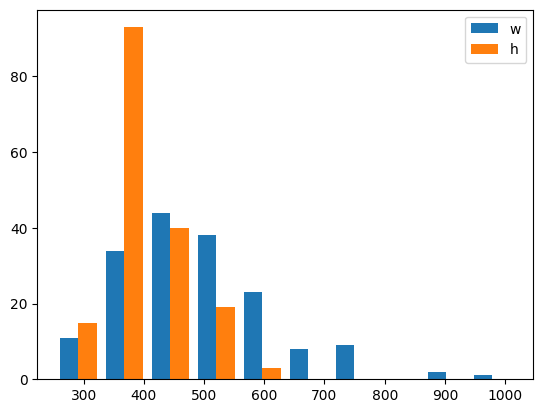

In [10]:
plt.hist(df, label=["w", "h"])
plt.legend()

In [11]:
results = check_dataset(dataset_dir, min_relative_area=0.005)

In [12]:
results

{'is_valid': True,
 'checked_annotations': 170,
 'total_boxes': 423,
 'small_boxes_count': 6,
 'errors': [],
 'small_boxes': [{'annotation': '/Users/anatolii/.cache/kagglehub/datasets/psvishnu/pennfudan-database-for-pedestrian-detection-zip/versions/1/PennFudanPed/Annotation/FudanPed00058.txt',
   'object_id': 5,
   'bbox': (427, 126, 446, 182),
   'relative_area': 0.00425535318631568,
   'threshold': 0.005},
  {'annotation': '/Users/anatolii/.cache/kagglehub/datasets/psvishnu/pennfudan-database-for-pedestrian-detection-zip/versions/1/PennFudanPed/Annotation/FudanPed00058.txt',
   'object_id': 6,
   'bbox': (462, 126, 474, 171),
   'relative_area': 0.0021596717298970557,
   'threshold': 0.005},
  {'annotation': '/Users/anatolii/.cache/kagglehub/datasets/psvishnu/pennfudan-database-for-pedestrian-detection-zip/versions/1/PennFudanPed/Annotation/FudanPed00058.txt',
   'object_id': 7,
   'bbox': (473, 133, 489, 183),
   'relative_area': 0.003199513673921564,
   'threshold': 0.005},
  {'an

In [13]:
dataset_report = create_yolo_dataset(dataset_dir, val_size=0.2)

In [14]:
dataset_report

{'data_dir': '/Users/anatolii/Projects/ml-engineering/pedestrian-box/data',
 'train_count': 136,
 'val_count': 34,
 'missing_images_for_labels': []}